# Biomedical Embedding Pipeline v2

A complete end-to-end pipeline for biomedical domain-adapted embedding research.

**Key features:**
- Sentence-aware chunking via `RecursiveCharacterTextSplitter`
- PDF + PMC XML support (reads your 300 Drive PDFs directly)
- Section context prepended to every chunk
- NVIDIA NIM API for synthetic query generation (higher rate limits)
- Fixed per-query-type recall@20 aggregation
- Explicit warning on training fallback
- Full Google Colab + local device compatibility
- GPU auto-detection for training

## 1) Setup & Environment Detection

In [1]:
import importlib.util, os, subprocess, sys, shutil
from pathlib import Path

# ── Detect environment ──
try:
    IN_COLAB = importlib.util.find_spec("google.colab") is not None
except ModuleNotFoundError:
    IN_COLAB = False
print(f"Environment: {'Google Colab' if IN_COLAB else 'Local Device'}")

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
    root = Path("/content/drive/MyDrive/LCM-Research")
    root.mkdir(parents=True, exist_ok=True)
    os.environ["LCM_PROJECT_ROOT"] = str(root)
    print(f"Drive mounted. Root: {root}")

# ── Install missing packages one by one with visible progress ──
REQUIRED = {
    "numpy": "numpy", "pandas": "pandas", "requests": "requests",
    "dotenv": "python-dotenv", "lxml": "lxml", "tqdm": "tqdm",
    "sentence_transformers": "sentence-transformers", "torch": "torch",
    "transformers": "transformers", "datasets": "datasets",
    "accelerate": "accelerate", "faiss": "faiss-cpu",
    "sklearn": "scikit-learn", "matplotlib": "matplotlib",
    "seaborn": "seaborn", "umap": "umap-learn",
    "pypdf": "pypdf",
    "langchain_text_splitters": "langchain-text-splitters",
    "bs4": "beautifulsoup4",
    "openai": "openai",
}

missing = [(mod, pip) for mod, pip in REQUIRED.items() if importlib.util.find_spec(mod) is None]

if not missing:
    print("All packages present.")
else:
    print(f"Installing {len(missing)} missing package(s)...\n")
    for idx, (mod, pip_name) in enumerate(missing, 1):
        print(f"[{idx}/{len(missing)}] Installing {pip_name}...", end=" ", flush=True)
        result = subprocess.run(
            [sys.executable, "-m", "pip", "install", "-q", pip_name],
            capture_output=True, text=True
        )
        if result.returncode == 0:
            print("OK")
        else:
            print(f"FAILED!")
            print(result.stderr[-500:] if result.stderr else "(no error output)")
    print("\nDone.")


Environment: Local Device
All packages present.


## 2) Imports + Configuration

In [2]:
from __future__ import annotations
import json, math, os, random, re, time, warnings
from collections import defaultdict
from datetime import datetime, timezone
from pathlib import Path
from typing import Dict, List, Optional, Sequence, Tuple

import numpy as np
import pandas as pd
import requests
from dotenv import load_dotenv
from lxml import etree
from tqdm.auto import tqdm
from langchain_text_splitters import RecursiveCharacterTextSplitter
from pypdf import PdfReader
import torch

# ── Re-detect Colab (needed after package installs may reset state) ──
IN_COLAB = False
try:
    import google.colab; IN_COLAB = True
except Exception:
    pass

# ── GPU Detection ──
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Compute device: {DEVICE}")
if DEVICE == "cuda":
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
    print(f"  VRAM: {torch.cuda.get_device_properties(0).total_mem / 1e9:.1f} GB")

# ── Project root ──
proj_env = os.getenv("LCM_PROJECT_ROOT", "").strip()
if proj_env:
    PROJECT_ROOT = Path(proj_env).expanduser()
elif IN_COLAB:
    PROJECT_ROOT = Path("/content/drive/MyDrive/LCM-Research")
else:
    PROJECT_ROOT = Path(".").resolve()
PROJECT_ROOT.mkdir(parents=True, exist_ok=True)

# ── Load API keys ──
# Priority: Colab Secrets > .env file > environment variables
def _load_api_keys():
    """Load API keys from best available source."""
    load_dotenv()
    env_path = PROJECT_ROOT / ".env"
    if env_path.exists():
        load_dotenv(dotenv_path=env_path, override=False)

    # Try Colab Secrets (most secure for Colab)
    if IN_COLAB:
        try:
            from google.colab import userdata
            for key_name in ["NVIDIA_API_KEY", "GROQ_API_KEY"]:
                try:
                    val = userdata.get(key_name)
                    if val:
                        os.environ[key_name] = val
                except Exception:
                    pass
        except ImportError:
            pass

_load_api_keys()

# ══════════════════════════════════════════════════════════════════════
# CONFIGURATION — edit this dict to control the entire pipeline
# ══════════════════════════════════════════════════════════════════════
CONFIG = {
    # Mode: True to run fully offline (uses pre-cached models & pairs)
    "offline_mode": False,
    # Mode: "prototype" (20 papers) | "full" (300 papers)
    "mode": "full",
    "prototype_paper_count": 20,
    "full_paper_count": 300,

    # ---------------------------------------------------------------
    # Set this to the Google Drive folder containing your 300 PDFs.
    # Example: "/content/drive/MyDrive/LCM-Research/data/raw_pdfs"
    # Leave empty to auto-use PROJECT_ROOT/data/raw_papers
    "pdf_input_dir": "",
    # ---------------------------------------------------------------

    # Reproducibility
    "random_seed": 42,
    "train_fraction": 0.80,           # 240 train / 60 test papers
    "force_recreate_split": False,

    # Chunking (sentence-aware, character-based)
    "chunk_size_chars": 800,
    "chunk_overlap_chars": 150,
    "min_chunk_chars": 120,
    "max_chunk_chars": 8000,
    "prepend_section_context": True,

    # Query generation — NVIDIA NIM (primary, higher rate limits)
    "run_query_generation": True,
    "llm_provider": os.getenv("LCM_LLM_PROVIDER", "nvidia").strip().lower(),
    "groq_model_name": os.getenv("GROQ_MODEL_NAME", "llama-3.3-70b-versatile"),
    "nvidia_model_name": os.getenv("NVIDIA_NIM_MODEL", "meta/llama-3.3-70b-instruct"),
    "nvidia_base_url": os.getenv("NVIDIA_NIM_BASE_URL", "https://integrate.api.nvidia.com/v1").rstrip("/"),
    "api_timeout_seconds": 180,
    "query_max_attempts": 4,
    "query_request_delay_seconds": 1.8,   # NVIDIA NIM: 40 RPM → 1.5s min + buffer
    "train_pairs_target": 6000,
    "test_pairs_target": 800,
    "min_query_chars": 24,
    "max_query_chars": 280,
    "min_query_token_overlap": 0.25,

    # Training
    "base_embedding_model": "sentence-transformers/all-MiniLM-L6-v2",
    "run_training": True,
    "training_use_hard_negatives": True,
    "training_epochs": 1,
    "training_batch_size": 16,
    "training_learning_rate": 2e-5,

    # Evaluation
    "run_evaluation": True,
    "eval_top_ks": [3, 5, 10, 20],
    "retrieval_batch_size": 64,

    # Novelty / baseline coverage
    "run_external_biomedical_baselines": True,
    "skip_failed_external_baselines": True,
    "external_embedding_models": {
        "BioBERT_sentence_baseline": "pritamdeka/BioBERT-mnli-snli-scinli-scitail-mednli-stsb",
        "PubMedBERT_embedding_baseline": "NeuML/pubmedbert-base-embeddings",
    },

    # Optional external benchmark alignment
    "run_external_benchmark_evaluation": False,
    "external_benchmark_source": "hf_nfcorpus",
    "external_benchmark_sample_queries": 200,
    "external_benchmark_sample_corpus": 5000,
    "external_benchmark_queries_path": str(PROJECT_ROOT / "data/benchmarks/queries.jsonl"),
    "external_benchmark_corpus_path": str(PROJECT_ROOT / "data/benchmarks/corpus.jsonl"),
    "external_benchmark_qrels_path": str(PROJECT_ROOT / "data/benchmarks/qrels.tsv"),
    "external_benchmark_results_csv": str(PROJECT_ROOT / "artifacts/biomedical_pipeline/external_benchmark_results.csv"),

    # Representation analysis
    "run_representation_analysis": True,
    "run_umap": True,
    "umap_sample_size": 800,

    "save_to_google_drive": IN_COLAB,
    "project_root": str(PROJECT_ROOT),
}

_pdf_cfg = CONFIG["pdf_input_dir"].strip()
PDF_INPUT_DIR = Path(_pdf_cfg) if _pdf_cfg else PROJECT_ROOT / "data/raw_papers"

PATHS = {
    "project_root":     PROJECT_ROOT,
    "raw_papers_dir":   PDF_INPUT_DIR,
    "chunks_csv":       PROJECT_ROOT / "data/processed_chunks/chunks.csv",
    "split_json":       PROJECT_ROOT / "data/splits/paper_split.json",
    "train_pairs_csv":  PROJECT_ROOT / "data/synthetic_pairs/train_pairs.csv",
    "test_pairs_csv":   PROJECT_ROOT / "data/synthetic_pairs/test_pairs.csv",
    "all_pairs_csv":    PROJECT_ROOT / "data/synthetic_pairs/all_pairs.csv",
    "model_dir":        PROJECT_ROOT / "models/biomedical_embedding_ft",
    "artifact_dir":     PROJECT_ROOT / "artifacts/biomedical_pipeline",
    "papers_csv":       PROJECT_ROOT / "artifacts/biomedical_pipeline/papers_extracted.csv",
    "eval_results_csv": PROJECT_ROOT / "artifacts/biomedical_pipeline/evaluation_results.csv",
    "eval_by_type_csv": PROJECT_ROOT / "artifacts/biomedical_pipeline/evaluation_by_query_type.csv",
    "similarity_csv":   PROJECT_ROOT / "artifacts/biomedical_pipeline/biomedical_term_similarity.csv",
    "neighbors_csv":    PROJECT_ROOT / "artifacts/biomedical_pipeline/nearest_neighbors.csv",
    "umap_png":         PROJECT_ROOT / "artifacts/biomedical_pipeline/umap_baseline_vs_ft.png",
    "baseline_index":   PROJECT_ROOT / "artifacts/biomedical_pipeline/baseline_test.index",
    "finetuned_index":  PROJECT_ROOT / "artifacts/biomedical_pipeline/finetuned_test.index",
    "external_eval_csv": PROJECT_ROOT / "artifacts/biomedical_pipeline/external_benchmark_results.csv",
    "index_map_csv":    PROJECT_ROOT / "artifacts/biomedical_pipeline/test_index_mapping.csv",
    "run_state_json":   PROJECT_ROOT / "artifacts/biomedical_pipeline/run_state.json",
}
for k, p in PATHS.items():
    if k == "project_root": continue
    (p.parent if p.suffix else p).mkdir(parents=True, exist_ok=True)

random.seed(CONFIG["random_seed"])
np.random.seed(CONFIG["random_seed"])
print(f"Project root : {PROJECT_ROOT}")
print(f"PDF input dir: {PDF_INPUT_DIR}")
print(f"Mode         : {CONFIG['mode']}")
print(f"LLM provider : {CONFIG['llm_provider']}")
print(f"Device       : {DEVICE}")

# ── Auto-configuration for Offline Mode ──
if CONFIG.get("offline_mode", False):
    print("\n>>> OFFLINE MODE ACTIVE: Overriding model paths and disabling network steps <<<")
    CONFIG["base_embedding_model"] = "models/all-MiniLM-L6-v2"
    CONFIG["run_query_generation"] = False
    CONFIG["run_external_benchmark_evaluation"] = False
    CONFIG["external_embedding_models"] = {
        "BioBERT_sentence_baseline": "models/BioBERT-sentence-baseline",
        "PubMedBERT_embedding_baseline": "models/PubMedBERT-embeddings",
    }
    # Ensure absolute paths resolved from PROJECT_ROOT
    for k, v in CONFIG["external_embedding_models"].items():
        if not Path(v).is_absolute():
            CONFIG["external_embedding_models"][k] = str(PROJECT_ROOT / v)
    if not Path(CONFIG["base_embedding_model"]).is_absolute():
        CONFIG["base_embedding_model"] = str(PROJECT_ROOT / CONFIG["base_embedding_model"])


Compute device: cpu
Project root : C:\Users\aashr\Desktop\Projects\LCM-Research
PDF input dir: C:\Users\aashr\Desktop\Projects\LCM-Research\data\raw_papers
Mode         : full
LLM provider : nvidia
Device       : cpu


## 3) File Discovery
Supports PDF and PMC XML.

In [3]:
def select_files(paths):
    if not paths:
        return []
    target = CONFIG["prototype_paper_count"] if CONFIG["mode"] == "prototype" else CONFIG["full_paper_count"]
    rng = random.Random(CONFIG["random_seed"])
    sp = sorted(paths, key=lambda p: p.stem)
    return sorted(rng.sample(sp, k=target), key=lambda p: p.stem) if len(sp) > target else sp

pdf_files = sorted(PDF_INPUT_DIR.glob("*.pdf"), key=lambda p: p.stem)
xml_files = sorted(PDF_INPUT_DIR.glob("*.xml"),  key=lambda p: p.stem)
all_files = pdf_files + xml_files
if not all_files:
    raise FileNotFoundError(
        f"No PDF or XML files in: {PDF_INPUT_DIR}\n"
        "Set CONFIG['pdf_input_dir'] to your Drive folder with the 300 PDFs."
    )
selected_files = select_files(all_files)
print(f"Found   : {len(pdf_files)} PDFs + {len(xml_files)} XML = {len(all_files)} total")
print(f"Selected: {len(selected_files)} ({CONFIG['mode']} mode)")
print("First 5 :", [f.name for f in selected_files[:5]])

Found   : 0 PDFs + 300 XML = 300 total
Selected: 300 (full mode)
First 5 : ['12960023.xml', '12960028.xml', '12960029.xml', '12960054.xml', '12960060.xml']


## 4) Text Extraction (PDF + XML)

In [4]:
FORMULA_TAGS = {"tex-math","inline-formula","disp-formula","mml:math","math"}

def normalize_text(text: str) -> str:
    """Normalize whitespace and non-breaking spaces."""
    text = str(text or "").replace("\u00a0", " ")
    return re.sub(r"\s+", " ", text).strip()

def is_informative(text: str) -> bool:
    if not text: return False
    if not (CONFIG["min_chunk_chars"] <= len(text) <= CONFIG["max_chunk_chars"]): return False
    if len(re.findall(r"[A-Za-z]{3,}", text)) < 10: return False
    if text.lower().startswith(("fig.","table ","supplementary figure")): return False
    return True

SECTION_RE = re.compile(
    r"^(abstract|introduction|background|methods?|materials?|results?|"
    r"discussion|conclusion|references?|supplementary|acknowledgements?)\b",
    re.IGNORECASE,
)

def extract_pdf(pdf_path: Path):
    paper_id = pdf_path.stem
    reader   = PdfReader(str(pdf_path))
    current_section = "body"
    passages = []
    all_text = []
    title    = f"PDF_{paper_id}"

    for page in reader.pages:
        raw = page.extract_text() or ""
        all_text.append(raw)
        for line in raw.split("\n"):
            s = line.strip()
            if SECTION_RE.match(s) and len(s) < 60:
                current_section = s.lower().split()[0].rstrip("s")
                continue
            t = normalize_text(s)
            if is_informative(t):
                passages.append({"paper_id": paper_id,"title": title,
                                  "section": current_section,"text": t,
                                  "source_path": str(pdf_path)})

    first_lines = [l.strip() for l in (all_text[0] if all_text else "").split("\n") if l.strip()]
    if first_lines:
        title = normalize_text(first_lines[0])[:200] or f"PDF_{paper_id}"
    for p in passages: p["title"] = title

    paper = {"paper_id": paper_id,"title": title,"abstract": "",
              "body_text": " ".join(all_text)[:5000],"source_path": str(pdf_path)}
    return paper, passages

def _local_tag(node):
    if not hasattr(node,"tag") or not isinstance(node.tag,str): return ""
    try: return etree.QName(node).localname
    except: return str(node.tag)

def _text_no_formula(node):
    parts = [node.text or ""]
    for child in node:
        if _local_tag(child) in FORMULA_TAGS:
            parts.append(child.tail or ""); continue
        parts.append(_text_no_formula(child)); parts.append(child.tail or "")
    return "".join(parts)

def extract_xml(xml_path: Path):
    paper_id = xml_path.stem
    root = etree.parse(str(xml_path), etree.XMLParser(recover=True, huge_tree=True)).getroot()
    title = normalize_text(root.xpath("string(.//article-title[1])")) or f"PMC_{paper_id}"
    passages = []
    for p in root.xpath(".//abstract//p"):
        t = normalize_text(_text_no_formula(p))
        if is_informative(t):
            passages.append({"paper_id":paper_id,"title":title,"section":"abstract",
                              "text":t,"source_path":str(xml_path)})
    for p in root.xpath(".//body//p"):
        t = normalize_text(_text_no_formula(p))
        if not is_informative(t): continue
        sec = normalize_text(p.xpath("string(ancestor::sec[1]/title)")) or "body"
        passages.append({"paper_id":paper_id,"title":title,"section":sec,
                          "text":t,"source_path":str(xml_path)})
    seen, dedup = set(), []
    for r in passages:
        k = (r["section"].lower(), r["text"])
        if k not in seen: seen.add(k); dedup.append(r)
    paper = {"paper_id":paper_id,"title":title,"abstract":"",
              "body_text":"\n\n".join(r["text"] for r in dedup)[:5000],
              "source_path":str(xml_path)}
    return paper, dedup

paper_rows, passage_rows = [], []
for fpath in tqdm(selected_files, desc="Extracting"):
    try:
        fn = extract_pdf if fpath.suffix.lower() == ".pdf" else extract_xml
        pr, prs = fn(fpath)
        paper_rows.append(pr); passage_rows.extend(prs)
    except Exception as exc:
        print(f"  WARN {fpath.name}: {exc}")

papers_df   = pd.DataFrame(paper_rows)
passages_df = pd.DataFrame(passage_rows)
if papers_df.empty or passages_df.empty:
    raise RuntimeError("No output. Check your input files and path.")
papers_df.to_csv(PATHS["papers_csv"], index=False)
print(f"Papers: {len(papers_df)} | Passages: {len(passages_df)}")

Extracting:   0%|          | 0/300 [00:00<?, ?it/s]

Papers: 300 | Passages: 14889


## 5) Sentence-Aware Chunking

`RecursiveCharacterTextSplitter` tries separators in order:
`\n\n` then `\n` then `. ` then word boundary.

This always produces syntactically complete sentences and embeds far more cleanly
than word-count slicing. Section context is prepended so the model learns that the
same sentence means different things in Methods vs Results.

In [5]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

_SPLITTER = RecursiveCharacterTextSplitter(
    chunk_size=CONFIG["chunk_size_chars"],
    chunk_overlap=CONFIG["chunk_overlap_chars"],
    separators=["\n\n", "\n", ". ", "? ", "! ", "; ", ", ", " ", ""],
    length_function=len,
    is_separator_regex=False,
)

def chunk_passage(text: str, section: str) -> List[str]:
    pieces = _SPLITTER.split_text(text)
    out = []
    for piece in pieces:
        piece = piece.strip()
        if len(piece) < CONFIG["min_chunk_chars"]:
            continue
        if CONFIG["prepend_section_context"] and section and section not in ("body", ""):
            piece = f"[{section}] {piece}"
        out.append(piece)
    return out

chunk_rows = []
paper_chunk_counts: Dict[str, int] = defaultdict(int)

for row in tqdm(passages_df.itertuples(index=False), total=len(passages_df), desc="Chunking"):
    for piece in chunk_passage(row.text, row.section):
        idx = paper_chunk_counts[row.paper_id]
        chunk_id = f"{row.paper_id}_{idx:05d}"
        paper_chunk_counts[row.paper_id] += 1
        chunk_rows.append({
            "chunk_id": chunk_id, "paper_id": row.paper_id, "title": row.title,
            "section": row.section, "text": piece, "source_path": row.source_path, "split": "",
        })

chunks_df = pd.DataFrame(chunk_rows)
if chunks_df.empty:
    raise RuntimeError("No chunks. Check min_chunk_chars or input files.")
chunks_df = chunks_df.drop_duplicates(subset=["chunk_id"]).reset_index(drop=True)
chunks_df = chunks_df[["chunk_id","paper_id","title","section","text","split","source_path"]]
chunks_df.to_csv(PATHS["chunks_csv"], index=False)

avg_len = chunks_df["text"].str.len().mean()
print(f"Chunks: {len(chunks_df)} | avg chars: {avg_len:.0f} (target {CONFIG['chunk_size_chars']})")
chunks_df.head(3)

Chunking:   0%|          | 0/14889 [00:00<?, ?it/s]

Chunks: 24166 | avg chars: 571 (target 800)


,chunk_id,paper_id,title,section,text,split,source_path
0,12960023_00000,12960023,"Michael R. Bristow, MD, PhD",body,"Michael R. Bristow, MD, PhD, was a defining fi...",,C:\Users\aashr\Desktop\Projects\LCM-Research\d...
1,12960023_00001,12960023,"Michael R. Bristow, MD, PhD",body,. Although our goal is to provide a glimpse in...,,C:\Users\aashr\Desktop\Projects\LCM-Research\d...
2,12960023_00002,12960023,"Michael R. Bristow, MD, PhD",Early Life,"[Early Life] Born in 1946, Mike grew up on a f...",,C:\Users\aashr\Desktop\Projects\LCM-Research\d...


## 6) Strict Document-Level Split (80/20 on papers)

In [6]:
def create_or_load_doc_split(paper_ids, split_path, train_fraction, seed, force=False):
    current = sorted({str(p) for p in paper_ids})
    if split_path.exists() and not force:
        saved = json.loads(split_path.read_text())
        tr = sorted(set(map(str, saved.get("train_papers",[]))).intersection(current))
        te = sorted(set(map(str, saved.get("test_papers", []))).intersection(current))
        missing = [p for p in current if p not in set(tr)|set(te)]
        if missing:
            rng = random.Random(seed); rng.shuffle(missing)
            cut = int(train_fraction * len(missing))
            tr.extend(missing[:cut]); te.extend(missing[cut:])
        tr = sorted(set(tr)); te = sorted(set(te))
    else:
        rng = random.Random(seed); shuffled = current[:]
        rng.shuffle(shuffled); cut = int(train_fraction * len(shuffled))
        tr = sorted(shuffled[:cut]); te = sorted(shuffled[cut:])

    assert tr and te, "Split produced an empty set."
    assert not set(tr) & set(te), "Paper leakage detected!"

    payload = {"created_at_utc": datetime.now(timezone.utc).isoformat(),
               "seed": seed, "train_fraction": train_fraction,
               "mode": CONFIG["mode"], "paper_count": len(current),
               "train_papers": tr, "test_papers": te}
    split_path.write_text(json.dumps(payload, indent=2))
    return set(tr), set(te), payload

train_papers, test_papers, _ = create_or_load_doc_split(
    paper_ids=chunks_df["paper_id"].astype(str).tolist(),
    split_path=PATHS["split_json"],
    train_fraction=CONFIG["train_fraction"],
    seed=CONFIG["random_seed"],
    force=CONFIG["force_recreate_split"],
)

chunks_df["paper_id"] = chunks_df["paper_id"].astype(str)
chunks_df["split"] = chunks_df["paper_id"].map(lambda p: "train" if p in train_papers else "test")
assert not (chunks_df["split"] == "").any(), "Unassigned chunks."
train_chunks_df = chunks_df[chunks_df["split"] == "train"].copy()
test_chunks_df  = chunks_df[chunks_df["split"] == "test"].copy()
assert set(train_chunks_df["paper_id"]).isdisjoint(set(test_chunks_df["paper_id"]))
chunks_df.to_csv(PATHS["chunks_csv"], index=False)
print(f"Train papers: {len(train_papers)} | Test papers: {len(test_papers)}")
print(f"Train chunks: {len(train_chunks_df)} | Test chunks: {len(test_chunks_df)}")
print(f"Paper overlap: {len(set(train_papers) & set(test_papers))}  (must be 0)")

Train papers: 237 | Test papers: 60
Train chunks: 18752 | Test chunks: 5414
Paper overlap: 0  (must be 0)


## 7) Query Generation Helpers

In [7]:
QUERY_TYPES = ["Factual", "Conversational", "Keyword Search", "Multi-Hop"]

def clean_query_text(raw: str) -> str:
    if not isinstance(raw, str): return ""
    q = raw.strip().replace("\u201c",'"').replace("\u201d",'"')
    q = re.sub(r"^```(?:json)?","",q,flags=re.IGNORECASE).strip()
    q = re.sub(r"```$","",q).strip()
    q = re.sub(r"^\s*(here'?s|here is|based on.*?passage)\b.*?:\s*","",
               q, flags=re.IGNORECASE|re.DOTALL).strip().strip("\"' ")
    m = re.search(r"(.+?\?)", q)
    return m.group(1).strip() if m else q

def tokenize_for_overlap(text: str):
    return [t for t in re.findall(r"[a-z0-9\-\+]+", str(text).lower()) if len(t) > 2]

def is_valid_query(query: str, chunk: str) -> bool:
    if not query or not query.endswith("?"): return False
    if not (CONFIG["min_query_chars"] <= len(query) <= CONFIG["max_query_chars"]): return False
    banned = ["based on the passage","this question is","it can be answered","using only the information"]
    if any(b in query.lower() for b in banned): return False
    q_toks = tokenize_for_overlap(query); c_toks = set(tokenize_for_overlap(chunk))
    if not q_toks: return False
    return sum(1 for t in q_toks if t in c_toks) / len(q_toks) >= CONFIG["min_query_token_overlap"]

def is_valid_hard_negative(hn: str, positive: str, query: str) -> bool:
    if not isinstance(hn, str) or len(hn.strip()) < 80: return False
    hn_n = normalize_text(hn)
    if hn_n == normalize_text(positive): return False
    pt = set(tokenize_for_overlap(positive)); ht = set(tokenize_for_overlap(hn_n))
    if not pt or not ht: return False
    j = len(pt & ht) / max(1, len(pt | ht))
    return 0.05 <= j <= 0.80 and query.lower() not in hn_n.lower()

def build_batch_generation_prompt(chunks: List[Dict], persona: str) -> str:
    style = {
        "Factual":        "Ask direct factual biomedical questions with specific measurable answers.",
        "Conversational": "Ask natural conversational questions a clinician or researcher might ask.",
        "Keyword Search": "Ask concise keyword-style biomedical search queries.",
        "Multi-Hop":      "Ask questions linking at least two distinct ideas in the chunk."
    }[persona]
    
    # Format the chunks into a clear list for the LLM
    chunks_text = "\n\n".join([f"--- CHUNK {i} ---\n{c['text']}" for i, c in enumerate(chunks)])
    
    return (
        "You are generating biomedical retrieval supervision data.\n"
        f"I am providing {len(chunks)} distinct text chunks below.\n\n"
        "Return a raw JSON array of objects. Do NOT wrap it in markdown blockquotes (```json). "
        "The array must contain exactly one object per chunk, in the same order, with these exact keys:\n"
        "- 'chunk_index': The integer index of the chunk (0, 1, 2...)\n"
        "- 'query': A specific question answerable ONLY by that chunk, ending with '?'.\n"
        "- 'hard_negative': A plausible biomedical paragraph that sounds similar but does NOT answer the query.\n\n"
        f"Persona: {persona}\nPersona guidance: {style}\n\n"
        f"Here are the chunks:\n{chunks_text}"
    )


## 8) TF-IDF Hard-Negative Miner + NVIDIA NIM API

Uses the NVIDIA NIM API (`integrate.api.nvidia.com/v1`) with `meta/llama-3.3-70b-instruct`.
The API is OpenAI-compatible. Free tier: **40 RPM** (requests per minute).

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import linear_kernel

def build_negative_miner(split_chunks: pd.DataFrame) -> Dict:
    docs      = split_chunks["text"].fillna("").tolist()
    vec       = TfidfVectorizer(min_df=2, max_features=50_000, ngram_range=(1,2))
    mat       = vec.fit_transform(docs)
    chunk_ids = split_chunks["chunk_id"].tolist()
    paper_ids = split_chunks["paper_id"].astype(str).tolist()
    return {"vec": vec, "mat": mat, "chunk_ids": chunk_ids,
            "paper_ids": paper_ids, "texts": docs,
            "id_to_idx": {cid: i for i, cid in enumerate(chunk_ids)}}

def mine_hard_negative(chunk_id: str, paper_id: str, miner: Dict, top_k: int=40) -> str:
    idx    = miner["id_to_idx"][chunk_id]
    sims   = linear_kernel(miner["mat"][idx], miner["mat"]).ravel()
    ranked = np.argsort(-sims)
    for ci in ranked[1:top_k+1]:
        if miner["paper_ids"][ci] != str(paper_id): return miner["texts"][ci]
    for ci in ranked[1:top_k+1]:
        if ci != idx: return miner["texts"][ci]
    return ""


def llm_credentials() -> Tuple[str, str, str]:
    provider = CONFIG["llm_provider"]
    if provider == "nvidia":
        return (
            CONFIG["nvidia_base_url"],
            CONFIG["nvidia_model_name"],
            os.getenv("NVIDIA_API_KEY", "").strip(),
        )
    if provider == "groq":
        return (
            "https://api.groq.com/openai/v1",
            CONFIG["groq_model_name"],
            os.getenv("GROQ_API_KEY", "").strip(),
        )
    raise ValueError(f"Unsupported llm_provider={provider!r}; use 'nvidia' or 'groq'.")

# ── Adaptive rate limiter for NVIDIA NIM (40 RPM) ──
_last_request_time = 0.0
_consecutive_errors = 0

def _adaptive_delay():
    """Calculate delay with exponential backoff on consecutive errors."""
    global _last_request_time, _consecutive_errors
    base_delay = CONFIG["query_request_delay_seconds"]
    if _consecutive_errors > 0:
        base_delay = min(base_delay * (2 ** _consecutive_errors), 60.0)
    elapsed = time.time() - _last_request_time
    if elapsed < base_delay:
        time.sleep(base_delay - elapsed)
    _last_request_time = time.time()

def call_llm(messages: List[Dict]) -> str:
    global _last_request_time, _consecutive_errors
    _adaptive_delay()
    base_url, model_name, api_key = llm_credentials()
    if not api_key:
        env_var = "NVIDIA_API_KEY" if CONFIG["llm_provider"] == "nvidia" else "GROQ_API_KEY"
        raise RuntimeError(
            f"{env_var} not set. Add it to .env, set it as an environment variable, "
            f"or add it to Colab Secrets (Key icon in left panel)."
        )
    payload = {"model": model_name, "messages": messages, "temperature": 0.15}
    try:
        resp = requests.post(
            f"{base_url}/chat/completions",
            headers={"Authorization": f"Bearer {api_key}", "Content-Type": "application/json"},
            json=payload,
            timeout=CONFIG["api_timeout_seconds"],
        )
        data = resp.json()
        if resp.status_code == 429:
            # Rate limited — back off
            _consecutive_errors += 1
            retry_after = float(resp.headers.get("Retry-After", 5))
            time.sleep(retry_after)
            raise RuntimeError(f"Rate limited (429). Backing off {retry_after}s.")
        if resp.status_code >= 400 or "error" in data:
            _consecutive_errors += 1
            raise RuntimeError(f"LLM API error status={resp.status_code}: {data.get('error', data)}")
        _consecutive_errors = max(0, _consecutive_errors - 1)  # decay on success
        return data["choices"][0]["message"].get("content") or ""
    except requests.exceptions.Timeout:
        _consecutive_errors += 1
        raise RuntimeError(f"LLM API timeout after {CONFIG['api_timeout_seconds']}s")
    except requests.exceptions.ConnectionError as exc:
        _consecutive_errors += 1
        raise RuntimeError(f"LLM API connection error: {exc}")

def generate_batch(chunks: List[Dict], persona: str) -> List[Dict]:
    """Sends multiple chunks to the LLM in one request."""
    prompt = build_batch_generation_prompt(chunks, persona)
    
    for attempt in range(CONFIG["query_max_attempts"]):
        try:
            raw = call_llm([{"role":"user","content":prompt}])
            # Clean LLM markdown wrappers
            text = re.sub(r"^```(?:json)?", "", raw, flags=re.IGNORECASE).strip()
            text = re.sub(r"```$", "", text).strip()
            
            results = json.loads(text)
            if isinstance(results, list) and len(results) == len(chunks):
                return results
            else:
                raise ValueError("LLM did not return the correct number of items.")
        except Exception as exc:
            if attempt + 1 == CONFIG["query_max_attempts"]:
                warnings.warn(f"Batch generation failed: {exc}", UserWarning, stacklevel=2)
                return []
            time.sleep(2 ** (attempt + 1))
    return []

## 9) Generate train_pairs.csv and test_pairs.csv

In [13]:
REQUIRED_COLS = ["query","positive_chunk","hard_negative","chunk_id","paper_id","split","query_type"]

def load_pairs(path: Path, split_name: str, require_complete: bool=True) -> pd.DataFrame:
    if not path.exists(): return pd.DataFrame(columns=REQUIRED_COLS)
    df = pd.read_csv(path)
    if "positive_chunk" not in df.columns and "chunk" in df.columns:
        df = df.rename(columns={"chunk":"positive_chunk"})
    for col in REQUIRED_COLS:
        if col not in df.columns: df[col] = ""
    df["split"] = split_name
    df = df[REQUIRED_COLS].drop_duplicates(subset=["chunk_id"])
    if require_complete:
        needed = ["query", "positive_chunk", "hard_negative", "chunk_id", "paper_id", "query_type"]
        df = df[df[needed].fillna("").astype(str).apply(lambda col: col.str.strip().ne(""), axis=0).all(axis=1)]
    return df

def generate_for_split(source_df, output_path, split_name, target, seed_offset):
    existing  = load_pairs(output_path, split_name)
    valid_ids = set(source_df["chunk_id"].tolist())
    existing  = existing[existing["chunk_id"].isin(valid_ids)].copy()
    
    if not CONFIG["run_query_generation"]:
        return {"total_after": len(existing)}

    miner     = build_negative_miner(source_df)
    processed = set(existing["chunk_id"].tolist())
    eligible  = source_df[~source_df["chunk_id"].isin(processed)]
    eligible  = eligible.sample(frac=1.0, random_state=CONFIG["random_seed"]+seed_offset)
    
    # Grab what we need to hit the target
    to_do_df  = eligible.head(max(0, target - len(existing)))
    to_do     = to_do_df.to_dict('records')
    
    new_records = []; kept = 0; skipped = 0
    start_time = time.time()
    
    # BATCH SIZE: 5 chunks per LLM call
    BATCH_SIZE = 5
    
    for i in tqdm(range(0, len(to_do), BATCH_SIZE), desc=f"Generating {split_name} (Batched)"):
        batch = to_do[i:i+BATCH_SIZE]
        persona = QUERY_TYPES[((i // BATCH_SIZE) + seed_offset) % len(QUERY_TYPES)]
        
        # Call LLM once for the whole batch
        llm_results = generate_batch(batch, persona)
        
        for j, row in enumerate(batch):
            query = hn = ""
            if j < len(llm_results):
                query = clean_query_text(llm_results[j].get("query", ""))
                hn    = normalize_text(llm_results[j].get("hard_negative", ""))
            
            if not is_valid_query(query, row['text']):
                skipped += 1; continue
            
            if not is_valid_hard_negative(hn, row['text'], query):
                hn = mine_hard_negative(str(row['chunk_id']), str(row['paper_id']), miner)
            
            if not is_valid_hard_negative(hn, row['text'], query):
                skipped += 1; continue
                
            new_records.append({
                "query": query, "positive_chunk": row['text'], "hard_negative": hn,
                "chunk_id": row['chunk_id'], "paper_id": str(row['paper_id']),
                "split": split_name, "query_type": persona
            })
            kept += 1
            
        # Checkpoint every ~25 pairs
        if len(new_records) >= 25 and len(new_records) % 25 < BATCH_SIZE:
            tmp = pd.concat([existing, pd.DataFrame(new_records)], ignore_index=True)
            tmp.drop_duplicates(subset=["chunk_id"]).to_csv(output_path, index=False)

    out = pd.concat([existing, pd.DataFrame(new_records)], ignore_index=True)
    out.drop_duplicates(subset=["chunk_id"]).to_csv(output_path, index=False)
    return {"kept_now": kept, "skipped_now": skipped, "total_after": len(out)}

if CONFIG["run_query_generation"]:
    _, active_model, _ = llm_credentials()
    print(f"Generating synthetic pairs with {CONFIG['llm_provider']}:{active_model}")
else:
    print("Query generation disabled; existing complete v2 pair files are required.")

train_stats = generate_for_split(train_chunks_df, PATHS["train_pairs_csv"], "train",
                                   CONFIG["train_pairs_target"], seed_offset=0)
test_stats  = generate_for_split(test_chunks_df,  PATHS["test_pairs_csv"],  "test",
                                   CONFIG["test_pairs_target"],  seed_offset=1000)
print("Train:", train_stats)
print("Test :", test_stats)

Generating synthetic pairs with nvidia:meta/llama-3.3-70b-instruct


Generating train (Batched):   0%|          | 0/6 [00:00<?, ?it/s]

Generating test (Batched):   0%|          | 0/35 [00:00<?, ?it/s]

Train: {'kept_now': 26, 'skipped_now': 2, 'total_after': 1998}
Test : {'kept_now': 172, 'skipped_now': 2, 'total_after': 498}


## 10) Integrity Validation

In [14]:
train_pairs_df = load_pairs(PATHS["train_pairs_csv"], "train")
test_pairs_df  = load_pairs(PATHS["test_pairs_csv"],  "test")
train_pairs_df["paper_id"] = train_pairs_df["paper_id"].astype(str)
test_pairs_df["paper_id"]  = test_pairs_df["paper_id"].astype(str)

def validate_pairs(tr, te, tr_papers, te_papers, tr_chunks, te_chunks):
    for name, df, papers, chunks in [("train",tr,tr_papers,tr_chunks),("test",te,te_papers,te_chunks)]:
        assert not df.empty,                      f"{name}_pairs is empty"
        assert (df["split"]==name).all(),          f"{name}_pairs split column mismatch"
        q_pct = df["query"].fillna("").str.endswith("?").mean()
        assert q_pct >= 0.90,                      f"{name} query quality < 90% ({q_pct:.1%})"
        assert set(df["chunk_id"].astype(str)).issubset(chunks), f"{name} chunk leak"
        assert set(df["paper_id"].astype(str)).issubset(papers), f"{name} paper leak"
    assert set(tr["chunk_id"].astype(str)).isdisjoint(set(te["chunk_id"].astype(str))), "Chunk overlap!"
    assert set(tr["paper_id"].astype(str)).isdisjoint(set(te["paper_id"].astype(str))), "Paper overlap!"
    print("All integrity checks passed.")

validate_pairs(
    train_pairs_df, test_pairs_df,
    set(map(str,train_papers)), set(map(str,test_papers)),
    set(train_chunks_df["chunk_id"].astype(str)),
    set(test_chunks_df["chunk_id"].astype(str)),
)
all_pairs_df = pd.concat([train_pairs_df,test_pairs_df],ignore_index=True)
all_pairs_df.to_csv(PATHS["all_pairs_csv"],index=False)
print(f"train_pairs: {len(train_pairs_df)} | test_pairs: {len(test_pairs_df)}")

All integrity checks passed.
train_pairs: 1998 | test_pairs: 498


## 11) Fine-Tuning

In [15]:
import torch, warnings
from torch.utils.data import DataLoader
from sentence_transformers import InputExample, SentenceTransformer, losses

def build_examples(df: pd.DataFrame, use_triplet: bool):
    examples = []
    if use_triplet:
        for row in df.itertuples(index=False):
            hn = normalize_text(getattr(row,"hard_negative",""))
            if hn: examples.append(InputExample(texts=[row.query, row.positive_chunk, hn]))
    if not examples:
        # Explicit warning -- silent in v1
        warnings.warn(
            "No valid hard-negative examples. Falling back to pairwise MultipleNegativesRankingLoss. "
            "Check your hard_negative column.",
            UserWarning, stacklevel=2,
        )
        for row in df.itertuples(index=False):
            examples.append(InputExample(texts=[row.query, row.positive_chunk]))
    return examples

def train_model(train_pairs: pd.DataFrame):
    model    = SentenceTransformer(CONFIG["base_embedding_model"], device=DEVICE)
    use_trip = (CONFIG["training_use_hard_negatives"] and
                train_pairs["hard_negative"].fillna("").str.len().gt(0).any())
    
    examples = build_examples(train_pairs, use_trip)
    loader   = DataLoader(examples, shuffle=True, batch_size=CONFIG["training_batch_size"])
    
    # THE FIX: MNRL natively accepts Triplets (Query, Positive, Hard Negative)
    # It will mathematically compare the Query against its Hard Negative AND all other Positives in the batch!
    loss_fn  = losses.MultipleNegativesRankingLoss(model=model)
    
    print(f"Loss function : MultipleNegativesRankingLoss (Using Triplets: {use_trip})")
    print(f"Examples      : {len(examples)}")
    print(f"Device        : {DEVICE}")
    
    model.fit(
        train_objectives=[(loader, loss_fn)],
        epochs=CONFIG["training_epochs"],
        warmup_steps=int(len(loader) * CONFIG["training_epochs"] * 0.10),
        optimizer_params={"lr": CONFIG["training_learning_rate"]},
        show_progress_bar=True,
        output_path=str(PATHS["model_dir"]),
    )
    
    (PATHS["artifact_dir"]/"training_config.json").write_text(
        json.dumps({"base_model":CONFIG["base_embedding_model"],
                    "trained_at":datetime.now(timezone.utc).isoformat(),
                    "epochs":CONFIG["training_epochs"],"batch_size":CONFIG["training_batch_size"],
                    "lr":CONFIG["training_learning_rate"],"triplet_loss":bool(use_trip),
                    "device":DEVICE,
                    "train_rows":len(train_pairs)},indent=2))
    print(f"Model saved -> {PATHS['model_dir']}")

if CONFIG["run_training"]:
    assert not train_pairs_df.empty, "train_pairs.csv empty."
    assert (train_pairs_df["split"] == "train").all(), "train_pairs has non-train rows."
    train_model(train_pairs_df)
else:
    print("Skipping training.")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loss function : MultipleNegativesRankingLoss (Using Triplets: True)
Examples      : 1998
Device        : cpu


Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

c:\Users\aashr\Desktop\Projects\LCM-Research\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved -> C:\Users\aashr\Desktop\Projects\LCM-Research\models\biomedical_embedding_ft


## 12) Retrieval Indexing (Baseline vs Fine-Tuned)

In [16]:
import faiss
from sentence_transformers import SentenceTransformer

def encode_l2(model, texts, bs=64):
    return model.encode(list(texts), batch_size=bs, show_progress_bar=True,
                         convert_to_numpy=True, normalize_embeddings=True).astype("float32")

def build_faiss(emb):
    idx = faiss.IndexFlatIP(emb.shape[1]); idx.add(emb); return idx

def safe_artifact_name(name: str) -> str:
    return re.sub(r"[^A-Za-z0-9_.-]+", "_", str(name)).strip("_")

retrieval_corpus_df = (test_chunks_df[["chunk_id","paper_id","title","section","text"]]
                       .drop_duplicates("chunk_id").reset_index(drop=True))
retrieval_corpus_df.to_csv(PATHS["index_map_csv"], index=False)
corpus_texts = retrieval_corpus_df["text"].fillna("").tolist()

model_registry = []

baseline_model  = SentenceTransformer(CONFIG["base_embedding_model"], device=DEVICE)
base_emb = encode_l2(baseline_model, corpus_texts, CONFIG["retrieval_batch_size"])
baseline_idx = build_faiss(base_emb)
faiss.write_index(baseline_idx, str(PATHS["baseline_index"]))
model_registry.append({"name":"general_baseline", "model_id":CONFIG["base_embedding_model"],
                       "model":baseline_model, "index":baseline_idx, "index_path":PATHS["baseline_index"]})

finetuned_model = SentenceTransformer(str(PATHS["model_dir"]), device=DEVICE)
ft_emb = encode_l2(finetuned_model, corpus_texts, CONFIG["retrieval_batch_size"])
finetuned_idx = build_faiss(ft_emb)
faiss.write_index(finetuned_idx, str(PATHS["finetuned_index"]))
model_registry.append({"name":"fine_tuned", "model_id":str(PATHS["model_dir"]),
                       "model":finetuned_model, "index":finetuned_idx, "index_path":PATHS["finetuned_index"]})

if CONFIG["run_external_biomedical_baselines"]:
    for model_name, model_id in CONFIG["external_embedding_models"].items():
        try:
            print(f"Loading external biomedical baseline: {model_name} -> {model_id}")
            ext_model = SentenceTransformer(model_id, device=DEVICE)
            ext_emb = encode_l2(ext_model, corpus_texts, CONFIG["retrieval_batch_size"])
            ext_idx = build_faiss(ext_emb)
            ext_path = PATHS["artifact_dir"] / f"{safe_artifact_name(model_name)}_test.index"
            faiss.write_index(ext_idx, str(ext_path))
            model_registry.append({"name":model_name, "model_id":model_id,
                                   "model":ext_model, "index":ext_idx, "index_path":ext_path})
        except Exception as exc:
            msg = f"External baseline {model_name} failed to load/evaluate: {exc}"
            if CONFIG["skip_failed_external_baselines"]:
                warnings.warn(msg, UserWarning, stacklevel=2)
            else:
                raise RuntimeError(msg) from exc

print(f"Corpus: {len(retrieval_corpus_df)} test chunks")
print("Models indexed:", [m["name"] for m in model_registry])

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/85 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/85 [00:00<?, ?it/s]

...

Batches:   0%|          | 0/85 [00:00<?, ?it/s]

Loading external biomedical baseline: PubMedBERT_embedding_baseline -> NeuML/pubmedbert-base-embeddings


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/85 [00:00<?, ?it/s]

Corpus: 5414 test chunks
Models indexed: ['general_baseline', 'fine_tuned', 'BioBERT_sentence_baseline', 'PubMedBERT_embedding_baseline']


## 13) Evaluation on Held-Out Test Pairs

In [17]:
def evaluate_retrieval(model, index, corpus_ids, test_pairs, top_ks):
    max_k  = max(top_ks)
    q_emb  = encode_l2(model, test_pairs["query"].fillna("").tolist(), CONFIG["retrieval_batch_size"])
    sc, ix = index.search(q_emb, max_k)
    id_lst = list(corpus_ids)
    rows   = []
    for i, row in enumerate(test_pairs.itertuples(index=False)):
        retrieved = [id_lst[j] for j in ix[i] if j >= 0]
        gold      = str(row.chunk_id)
        rank      = next((r for r, cid in enumerate(retrieved,1) if cid == gold), None)
        m = {}
        for k in top_ks:
            m[f"recall@{k}"] = 1.0 if rank and rank <= k else 0.0
        m["hit_rate@3"] = 1.0 if rank and rank <= 3 else 0.0
        m["mrr"]        = 1.0 / rank if rank else 0.0
        m["ndcg@10"]    = (1.0/math.log2(rank+1)) if rank and rank <= 10 else 0.0
        rows.append({"query":row.query,"query_type":row.query_type,
                      "chunk_id":gold,"rank":rank or -1,**m})
    per_q = pd.DataFrame(rows)
    agg   = {"MRR":per_q["mrr"].mean(),"NDCG@10":per_q["ndcg@10"].mean(),
             "HitRate@3":per_q["hit_rate@3"].mean()}
    for k in top_ks: agg[f"Recall@{k}"] = per_q[f"recall@{k}"].mean()
    return agg, per_q

assert set(test_pairs_df["paper_id"].astype(str)).issubset(set(map(str,test_papers)))

corpus_ids = retrieval_corpus_df["chunk_id"].astype(str).tolist()
comparison_rows, per_query_frames = [], []
for spec in model_registry:
    agg, per_q = evaluate_retrieval(spec["model"], spec["index"], corpus_ids, test_pairs_df, CONFIG["eval_top_ks"])
    comparison_rows.append({"model":spec["name"], "model_id":spec["model_id"], **agg})
    per_q.insert(0, "model", spec["name"])
    per_query_frames.append(per_q)

comparison_df = pd.DataFrame(comparison_rows)
comparison_df.to_csv(PATHS["eval_results_csv"], index=False)
print("\n" + "="*80)
print("EVALUATION RESULTS")
print("="*80)
print(comparison_df.to_string(index=False))
print("="*80)

# Per-type breakdown across baseline, fine-tuned, and external biomedical baselines.
def per_type_summary(per_q):
    metric_cols = ["mrr","ndcg@10","hit_rate@3"] + [f"recall@{k}" for k in CONFIG["eval_top_ks"]]
    existing    = [c for c in metric_cols if c in per_q.columns]
    agg_dict    = {c: (c,"mean") for c in existing}
    agg_dict["queries"] = ("query","count")
    return per_q.groupby(["model", "query_type"],dropna=False).agg(**agg_dict).reset_index()

all_per_q = pd.concat(per_query_frames, ignore_index=True)
by_type = per_type_summary(all_per_q)
by_type.to_csv(PATHS["eval_by_type_csv"],index=False)
print("\nPer query-type breakdown:")
by_type

Batches:   0%|          | 0/8 [00:00<?, ?it/s]

Batches:   0%|          | 0/8 [00:00<?, ?it/s]

Batches:   0%|          | 0/8 [00:00<?, ?it/s]

Batches:   0%|          | 0/8 [00:00<?, ?it/s]


EVALUATION RESULTS
                        model                                                                    model_id      MRR  NDCG@10  HitRate@3  Recall@3  Recall@5  Recall@10  Recall@20
             general_baseline                                      sentence-transformers/all-MiniLM-L6-v2 0.635232 0.685755   0.710843  0.710843  0.789157   0.859438   0.927711
                   fine_tuned C:\Users\aashr\Desktop\Projects\LCM-Research\models\biomedical_embedding_ft 0.707756 0.756658   0.797189  0.797189  0.849398   0.917671   0.959839
    BioBERT_sentence_baseline                     pritamdeka/BioBERT-mnli-snli-scinli-scitail-mednli-stsb 0.613354 0.666743   0.692771  0.692771  0.748996   0.849398   0.913655
PubMedBERT_embedding_baseline                                            NeuML/pubmedbert-base-embeddings 0.630762 0.688382   0.700803  0.700803  0.785141   0.883534   0.943775

Per query-type breakdown:


,model,query_type,mrr,ndcg@10,hit_rate@3,recall@3,recall@5,recall@10,recall@20,queries
0,BioBERT_sentence_baseline,Conversational,0.612384,0.670114,0.716667,0.716667,0.783333,0.866667,0.941667,120
1,BioBERT_sentence_baseline,Factual,0.566226,0.618898,0.625000,0.625000,0.695312,0.804688,0.890625,128
2,BioBERT_sentence_baseline,Keyword Search,0.574153,0.629973,0.645669,0.645669,0.700787,0.818898,0.874016,127
3,BioBERT_sentence_baseline,Multi-Hop,0.703818,0.751212,0.788618,0.788618,0.821138,0.910569,0.951220,123
4,PubMedBERT_embedding_baseline,Conversational,0.630679,0.693570,0.675000,0.675000,0.783333,0.908333,0.958333,120
5,PubMedBERT_embedding_baseline,Factual,0.593378,0.644663,0.640625,0.640625,0.734375,0.828125,0.921875,128
6,PubMedBERT_embedding_baseline,Keyword Search,0.604056,0.661724,0.669291,0.669291,0.748031,0.858268,0.921260,127
7,PubMedBERT_embedding_baseline,Multi-Hop,0.697323,0.756344,0.821138,0.821138,0.878049,0.943089,0.975610,123
8,fine_tuned,Conversational,0.711683,0.765924,0.816667,0.816667,0.891667,0.941667,0.983333,120
9,fine_tuned,Factual,0.703739,0.748895,0.773438,0.773438,0.828125,0.898438,0.937500,128


## 14) Optional External Benchmark Alignment

This section evaluates the same model registry on BEIR/NFCorpus or local BEIR-style files when enabled. It is separate from the internal synthetic-query test so the paper can report both in-domain controlled evaluation and an external benchmark sanity check.

In [18]:
def _read_jsonl(path: Path) -> pd.DataFrame:
    rows = []
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return pd.DataFrame(rows)

def load_local_beir_like_benchmark():
    q_path = Path(CONFIG["external_benchmark_queries_path"])
    c_path = Path(CONFIG["external_benchmark_corpus_path"])
    r_path = Path(CONFIG["external_benchmark_qrels_path"])
    missing = [str(p) for p in [q_path, c_path, r_path] if not p.exists()]
    if missing:
        raise FileNotFoundError("Missing local benchmark files: " + ", ".join(missing))
    queries = _read_jsonl(q_path).rename(columns={"_id":"query_id", "text":"query"})
    corpus = _read_jsonl(c_path).rename(columns={"_id":"doc_id"})
    qrels = pd.read_csv(r_path, sep="\t", names=["query_id", "doc_id", "score"])
    return corpus, queries, qrels

def load_hf_nfcorpus_benchmark():
    from datasets import load_dataset
    corpus = load_dataset("BeIR/nfcorpus", "corpus", split="corpus").to_pandas()
    queries = load_dataset("BeIR/nfcorpus", "queries", split="queries").to_pandas()
    try:
        qrels = load_dataset("BeIR/nfcorpus-qrels", split="test").to_pandas()
    except Exception:
        qrels = load_dataset("BeIR/nfcorpus-qrels")["test"].to_pandas()
    corpus = corpus.rename(columns={"_id":"doc_id"})
    queries = queries.rename(columns={"_id":"query_id", "text":"query"})
    qrels = qrels.rename(columns={"query-id":"query_id", "corpus-id":"doc_id"})
    if "score" not in qrels.columns:
        qrels["score"] = 1
    return corpus, queries, qrels

def prepare_benchmark_frames(corpus, queries, qrels):
    corpus = corpus.copy(); queries = queries.copy(); qrels = qrels.copy()
    corpus["doc_id"] = corpus["doc_id"].astype(str)
    queries["query_id"] = queries["query_id"].astype(str)
    qrels["query_id"] = qrels["query_id"].astype(str)
    qrels["doc_id"] = qrels["doc_id"].astype(str)
    corpus["text_for_embedding"] = (corpus.get("title", "").fillna("").astype(str) + " " +
                                      corpus.get("text", "").fillna("").astype(str)).str.strip()
    qrels = qrels[qrels["score"].astype(float) > 0]
    valid_queries = set(qrels["query_id"]).intersection(set(queries["query_id"]))
    valid_docs = set(qrels["doc_id"]).intersection(set(corpus["doc_id"]))
    qrels = qrels[qrels["query_id"].isin(valid_queries) & qrels["doc_id"].isin(valid_docs)].copy()
    queries = queries[queries["query_id"].isin(set(qrels["query_id"]))].copy()
    corpus = corpus[corpus["doc_id"].isin(valid_docs)].copy()
    if CONFIG["external_benchmark_sample_queries"]:
        keep_q = set(queries.sample(min(len(queries), CONFIG["external_benchmark_sample_queries"]),
                                    random_state=CONFIG["random_seed"])["query_id"])
        qrels = qrels[qrels["query_id"].isin(keep_q)]
        queries = queries[queries["query_id"].isin(keep_q)]
        needed_docs = set(qrels["doc_id"])
        extra = corpus[~corpus["doc_id"].isin(needed_docs)]
        if CONFIG["external_benchmark_sample_corpus"]:
            room = max(0, CONFIG["external_benchmark_sample_corpus"] - len(needed_docs))
            extra = extra.sample(min(len(extra), room), random_state=CONFIG["random_seed"])
        corpus = pd.concat([corpus[corpus["doc_id"].isin(needed_docs)], extra], ignore_index=True)
    return corpus.reset_index(drop=True), queries.reset_index(drop=True), qrels.reset_index(drop=True)

def evaluate_beir_like(model, corpus, queries, qrels, top_ks):
    doc_ids = corpus["doc_id"].astype(str).tolist()
    qrels_by_q = {qid: dict(zip(g["doc_id"].astype(str), g["score"].astype(float)))
                  for qid, g in qrels.groupby("query_id")}
    corpus_emb = encode_l2(model, corpus["text_for_embedding"].fillna("").tolist(), CONFIG["retrieval_batch_size"])
    idx = build_faiss(corpus_emb)
    query_emb = encode_l2(model, queries["query"].fillna("").tolist(), CONFIG["retrieval_batch_size"])
    _, hits = idx.search(query_emb, max(top_ks))
    rows = []
    for i, row in enumerate(queries.itertuples(index=False)):
        rel = qrels_by_q.get(str(row.query_id), {})
        if not rel:
            continue
        retrieved = [doc_ids[j] for j in hits[i] if j >= 0]
        first_rank = next((r for r, did in enumerate(retrieved, 1) if did in rel), None)
        metrics = {"mrr": 1.0 / first_rank if first_rank else 0.0}
        ideal_scores = sorted(rel.values(), reverse=True)
        for k in top_ks:
            got = retrieved[:k]
            metrics[f"recall@{k}"] = len(set(got) & set(rel)) / max(1, len(rel))
        dcg = sum((rel.get(did, 0.0) / math.log2(rank + 1)) for rank, did in enumerate(retrieved[:10], 1))
        idcg = sum((score / math.log2(rank + 1)) for rank, score in enumerate(ideal_scores[:10], 1))
        metrics["ndcg@10"] = dcg / idcg if idcg else 0.0
        rows.append(metrics)
    per_q = pd.DataFrame(rows)
    agg = {"MRR": per_q["mrr"].mean(), "NDCG@10": per_q["ndcg@10"].mean(),
           "queries": len(per_q), "corpus_docs": len(corpus)}
    for k in top_ks:
        agg[f"Recall@{k}"] = per_q[f"recall@{k}"].mean()
    return agg

if CONFIG["run_external_benchmark_evaluation"]:
    if CONFIG["external_benchmark_source"] == "hf_nfcorpus":
        corpus_b, queries_b, qrels_b = load_hf_nfcorpus_benchmark()
        benchmark_name = "BEIR/NFCorpus"
    elif CONFIG["external_benchmark_source"] == "local_beir":
        corpus_b, queries_b, qrels_b = load_local_beir_like_benchmark()
        benchmark_name = "local_beir_like"
    else:
        raise ValueError("external_benchmark_source must be 'hf_nfcorpus' or 'local_beir'.")
    corpus_b, queries_b, qrels_b = prepare_benchmark_frames(corpus_b, queries_b, qrels_b)
    rows = []
    for spec in model_registry:
        print(f"External benchmark: {benchmark_name} with {spec['name']}")
        rows.append({"benchmark":benchmark_name, "model":spec["name"], "model_id":spec["model_id"],
                     **evaluate_beir_like(spec["model"], corpus_b, queries_b, qrels_b, CONFIG["eval_top_ks"])})
    external_benchmark_df = pd.DataFrame(rows)
    external_benchmark_df.to_csv(PATHS["external_eval_csv"], index=False)
    print(external_benchmark_df.to_string(index=False))
else:
    print("External BEIR/BioASQ-style benchmark skipped. Set CONFIG['run_external_benchmark_evaluation']=True to run it.")

External BEIR/BioASQ-style benchmark skipped. Set CONFIG['run_external_benchmark_evaluation']=True to run it.


## 15) Representation Analysis (Cosine Similarity + UMAP)

               term_a                term_b  baseline_cosine  finetuned_cosine     delta
myocardial infarction          heart attack         0.593563          0.568044 -0.025519
        hyperglycemia    high blood glucose         0.668326          0.622500 -0.045826
             neoplasm                 tumor         0.589951          0.578753 -0.011198
         hypertension   high blood pressure         0.726550          0.687571 -0.038979
           metastasis          tumor spread         0.501632          0.469204 -0.032428
            apoptosis programmed cell death         0.614442          0.595386 -0.019056
             ischemia    oxygen deprivation         0.355961          0.355085 -0.000876


Batches:   0%|          | 0/13 [00:00<?, ?it/s]

Batches:   0%|          | 0/13 [00:00<?, ?it/s]

c:\Users\aashr\Desktop\Projects\LCM-Research\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


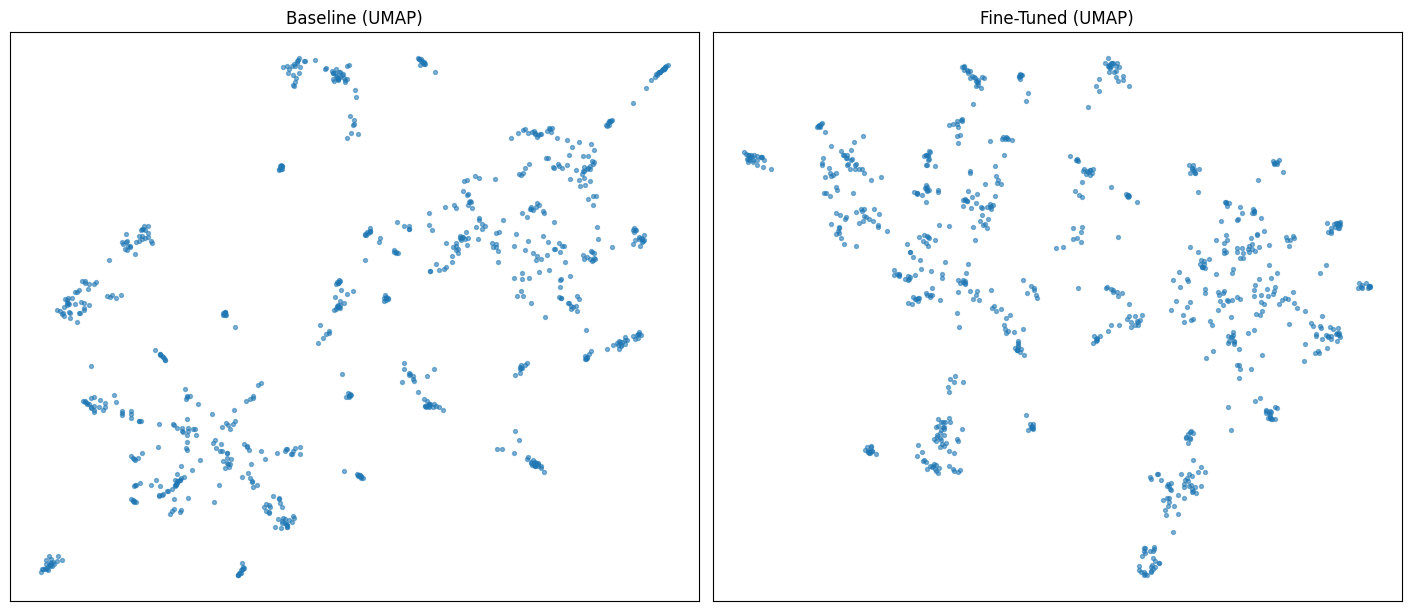

In [19]:
import matplotlib.pyplot as plt

def cosine(a, b):
    d = np.linalg.norm(a) * np.linalg.norm(b)
    return float(np.dot(a,b)/d) if d else 0.0

TERM_PAIRS = [
    ("myocardial infarction","heart attack"),
    ("hyperglycemia","high blood glucose"),
    ("neoplasm","tumor"),
    ("hypertension","high blood pressure"),
    ("metastasis","tumor spread"),
    ("apoptosis","programmed cell death"),
    ("ischemia","oxygen deprivation"),
]
sim_rows = []
for a_t, b_t in TERM_PAIRS:
    a_b = baseline_model.encode([a_t],  normalize_embeddings=True)[0]
    b_b = baseline_model.encode([b_t],  normalize_embeddings=True)[0]
    a_f = finetuned_model.encode([a_t], normalize_embeddings=True)[0]
    b_f = finetuned_model.encode([b_t], normalize_embeddings=True)[0]
    sim_rows.append({"term_a":a_t,"term_b":b_t,
                      "baseline_cosine":cosine(a_b,b_b),
                      "finetuned_cosine":cosine(a_f,b_f),
                      "delta":cosine(a_f,b_f)-cosine(a_b,b_b)})
sim_df = pd.DataFrame(sim_rows)
sim_df.to_csv(PATHS["similarity_csv"], index=False)
print(sim_df.to_string(index=False))

if CONFIG["run_umap"]:
    try:
        import umap as umap_lib
        n = min(CONFIG["umap_sample_size"], len(retrieval_corpus_df))
        samp    = retrieval_corpus_df.sample(n=n, random_state=CONFIG["random_seed"]).reset_index(drop=True)
        b_samp  = encode_l2(baseline_model,  samp["text"].tolist(), 64)
        f_samp  = encode_l2(finetuned_model, samp["text"].tolist(), 64)
        reducer = umap_lib.UMAP(n_neighbors=20, min_dist=0.1, metric="cosine",
                                 random_state=CONFIG["random_seed"])
        b_xy = reducer.fit_transform(b_samp)
        f_xy = reducer.fit_transform(f_samp)
        fig, axes = plt.subplots(1,2,figsize=(14,6),constrained_layout=True)
        axes[0].scatter(b_xy[:,0],b_xy[:,1],s=8,alpha=0.55); axes[0].set_title("Baseline (UMAP)")
        axes[1].scatter(f_xy[:,0],f_xy[:,1],s=8,alpha=0.55); axes[1].set_title("Fine-Tuned (UMAP)")
        for ax in axes: ax.set_xticks([]); ax.set_yticks([])
        fig.savefig(PATHS["umap_png"],dpi=180); plt.show()
    except ImportError:
        print("UMAP not available; skipping.")

## 16) Artifact Summary

In [20]:
expected = [PATHS["chunks_csv"],PATHS["split_json"],
             PATHS["train_pairs_csv"],PATHS["test_pairs_csv"],PATHS["all_pairs_csv"],
             PATHS["model_dir"],PATHS["eval_results_csv"],PATHS["eval_by_type_csv"],
             PATHS["similarity_csv"],PATHS["umap_png"], PATHS["external_eval_csv"],
             PATHS["baseline_index"],PATHS["finetuned_index"]]
summary = [{"artifact":str(p),"exists":p.exists(),
             "size_bytes":p.stat().st_size if p.exists() and p.is_file() else None}
           for p in expected]
pd.DataFrame(summary)

,artifact,exists,size_bytes
0,C:\Users\aashr\Desktop\Projects\LCM-Research\d...,True,20215987.0
1,C:\Users\aashr\Desktop\Projects\LCM-Research\d...,True,5243.0
2,C:\Users\aashr\Desktop\Projects\LCM-Research\d...,True,1880274.0
3,C:\Users\aashr\Desktop\Projects\LCM-Research\d...,True,465388.0
4,C:\Users\aashr\Desktop\Projects\LCM-Research\d...,True,2345591.0
5,C:\Users\aashr\Desktop\Projects\LCM-Research\m...,True,NaN
6,C:\Users\aashr\Desktop\Projects\LCM-Research\a...,True,896.0
7,C:\Users\aashr\Desktop\Projects\LCM-Research\a...,True,2552.0
8,C:\Users\aashr\Desktop\Projects\LCM-Research\a...,True,679.0
9,C:\Users\aashr\Desktop\Projects\LCM-Research\a...,True,179261.0
